# CP3.1 — Pre-Race (Forecasting) Model
**Thesis:** Predicting F1 Race Finishing Positions (2022–2025 ground-effect era), ensemble ML + SHAP.

Parallel track to CP3. Trains the **same** RandomForest + XGBoost on the **pre-race feature set**
(`data/processed/pre_race/`) — only quantities knowable **before lights-out** (grid, prior-race form,
circuit, declared starting tyre, weather forecast). No in-race pace/strategy/incident features.

This is the honest **forecasting** model; CP3 (full feature set) is the **reconstruction / explanation**
model. Compare the two: CP3 explains *what drove* the result, CP3.1 tests *how far ahead we can predict*.
Same protocol — GroupKFold(5) by race, train 2022–24, test on held-out 2025, naive baselines.
**No SHAP (CP4). No model export (CP5).**

## Setup

In [1]:
from pathlib import Path
import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             make_scorer)
from scipy.stats import spearmanr
from xgboost import XGBRegressor

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PRE = ROOT / "data" / "processed" / "pre_race"
MODELS_DIR = ROOT / "models"; MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = ROOT / "reports" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
                     "axes.titleweight": "bold"})
saved_figures = []
def save_fig(fig, name):
    fig.savefig(FIG_DIR / name); saved_figures.append(name)
    print("  saved ->", f"reports/figures/{name}")

train_df = pd.read_csv(PRE / "pre_race_train.csv")
test_df = pd.read_csv(PRE / "pre_race_test.csv")
FEATURES = json.load(open(MODELS_DIR / "pre_race_feature_list.json"))
TARGET = "final_position"
print("Train:", train_df.shape, "| Test:", test_df.shape, "| Pre-race features:", len(FEATURES))
print("Features:", FEATURES)
train_df.head(3)

Train: (1350, 18) | Test: (476, 18) | Pre-race features: 13
Features: ['grid_position', 'season', 'total_race_laps', 'is_street_circuit', 'driver_rolling_avg_3', 'driver_rolling_avg_5', 'driver_dnf_rate_season', 'driver_encoded', 'constructor_rolling_avg_points_3', 'constructor_season_points', 'team_encoded', 'compound_encoded', 'is_wet_race']


,season,round,driver_abbrev,team,dnf,grid_position,total_race_laps,is_street_circuit,driver_rolling_avg_3,driver_rolling_avg_5,driver_dnf_rate_season,driver_encoded,constructor_rolling_avg_points_3,constructor_season_points,team_encoded,compound_encoded,is_wet_race,final_position
0,2022,1,ALB,Williams,False,14.0,57.0,False,NaN,NaN,NaN,0,NaN,NaN,9,0,False,13.0
1,2022,1,ALO,Alpine,False,8.0,57.0,False,NaN,NaN,NaN,1,NaN,NaN,0,0,False,9.0
2,2022,1,BOT,Kick Sauber,False,6.0,57.0,False,NaN,NaN,NaN,5,NaN,NaN,4,0,False,6.0


## Known-Issue Handling (before training)
Identical policy to CP3: rookie code remap + principled NaN fill. Fit nothing on the test set.

In [2]:
# --- (a) Unseen rookie driver codes -> median TRAIN driver code ---
known_driver_codes = set(train_df["driver_encoded"].unique())
known_team_codes = set(train_df["team_encoded"].unique())
median_driver_code = int(np.round(train_df["driver_encoded"].median()))
median_team_code = int(np.round(train_df["team_encoded"].median()))

unseen_drivers = sorted(set(test_df["driver_encoded"]) - known_driver_codes)
rookie_abbrev = sorted(test_df.loc[~test_df["driver_encoded"].isin(known_driver_codes), "driver_abbrev"].unique())
test_df["driver_encoded"] = test_df["driver_encoded"].where(
    test_df["driver_encoded"].isin(known_driver_codes), median_driver_code)
test_df["team_encoded"] = test_df["team_encoded"].where(
    test_df["team_encoded"].isin(known_team_codes), median_team_code)
print(f"Unseen driver codes {unseen_drivers} ({rookie_abbrev}) -> median code {median_driver_code}")

# --- (b) constructor_season_points: NaN = season start = genuinely 0 points ---
for d in (train_df, test_df):
    d["constructor_season_points"] = d["constructor_season_points"].fillna(0.0)
print("constructor_season_points NaN filled with 0 (true value at season start).")

# --- Build matrices (DataFrame keeps FEATURES order for any later SHAP) ---
X_train, y_train = train_df[FEATURES].copy(), train_df[TARGET].values
X_test, y_test = test_df[FEATURES].copy(), test_df[TARGET].values
print("Remaining NaNs -> train:", int(X_train.isna().sum().sum()),
      "test:", int(X_test.isna().sum().sum()), "(median-imputed next, inside the pipeline)")

Unseen driver codes [2, 4, 10] (['ANT', 'BOR', 'HAD']) -> median code 19
constructor_season_points NaN filled with 0 (true value at season start).
Remaining NaNs -> train: 144 test: 27 (median-imputed next, inside the pipeline)


## Imputer (median; fit on train only) & Pipelines
Same RF / XGBoost hyper-parameters as CP3 for a fair feature-set comparison. The imputer is saved
separately as `pre_race_imputer.pkl` so CP3's `imputer.pkl` is untouched.

In [3]:
imputer = SimpleImputer(strategy="median").fit(X_train)
with open(MODELS_DIR / "pre_race_imputer.pkl", "wb") as f:
    pickle.dump(imputer, f)
print("Saved models/pre_race_imputer.pkl (median, fit on train only)")

rf = RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_leaf=2,
                           max_features="sqrt", random_state=42, n_jobs=-1)
xgb = XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.05, subsample=0.8,
                   colsample_bytree=0.8, min_child_weight=3, random_state=42, n_jobs=-1)
rf_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", rf)])
xgb_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", xgb)])
print("Pipelines ready: RF and XGBoost (imputer + model).")

Saved models/pre_race_imputer.pkl (median, fit on train only)
Pipelines ready: RF and XGBoost (imputer + model).


## Cross-Validation (5-fold GroupKFold by race)
Groups = `(season, round)` so all driver rows of a race stay in one fold.

In [4]:
groups = (train_df["season"].astype(int) * 100 + train_df["round"].astype(int)).values
print("CV groups (distinct races in train):", len(np.unique(groups)))
gkf = GroupKFold(n_splits=5)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

rf_cv = -cross_val_score(rf_pipe, X_train, y_train, cv=gkf, groups=groups, scoring=mae_scorer)
xgb_cv = -cross_val_score(xgb_pipe, X_train, y_train, cv=gkf, groups=groups, scoring=mae_scorer)
print(f"RF  CV MAE: {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")
print(f"XGB CV MAE: {xgb_cv.mean():.3f} ± {xgb_cv.std():.3f}")

CV groups (distinct races in train): 68
RF  CV MAE: 3.248 ± 0.105
XGB CV MAE: 3.474 ± 0.113


## Fit on full train, predict 2025 test

In [5]:
rf_pipe.fit(X_train, y_train)
xgb_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
xgb_pred = xgb_pipe.predict(X_test)
print("Predictions generated for", len(y_test), "test rows.")

Predictions generated for 476 test rows.


## Evaluation Metrics (2025 test)
Raw floats for MAE/R²/Spearman; **rounded** predictions for accuracy buckets; plus per-race
mean Spearman (within-race ranking quality).

In [6]:
test_races = (test_df["season"].astype(int) * 100 + test_df["round"].astype(int)).values

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sp_r, sp_p = spearmanr(y_true, y_pred)
    per = []
    for g in np.unique(test_races):
        m = test_races == g
        if m.sum() > 2:
            per.append(spearmanr(y_true[m], y_pred[m]).correlation)
    per_race_sp = np.nanmean(per)
    yr = np.round(y_pred)
    res = {"name": name, "mae": mae, "rmse": rmse, "r2": r2, "spearman": sp_r,
           "spearman_p": sp_p, "per_race_spearman": per_race_sp,
           "exact": np.mean(np.abs(yr - y_true) == 0),
           "within_1": np.mean(np.abs(yr - y_true) <= 1),
           "within_3": np.mean(np.abs(yr - y_true) <= 3),
           "within_5": np.mean(np.abs(yr - y_true) <= 5)}
    print(f"\n=== {name} (pre-race) ===")
    print(f"MAE        : {mae:.3f} positions")
    print(f"RMSE       : {rmse:.3f}")
    print(f"R²         : {r2:.3f}")
    print(f"Spearman r : {sp_r:.3f} (p={sp_p:.4f}) | per-race mean: {per_race_sp:.3f}")
    print(f"Exact      : {res['exact']:.1%}")
    print(f"Within ±1  : {res['within_1']:.1%}")
    print(f"Within ±3  : {res['within_3']:.1%}")
    print(f"Within ±5  : {res['within_5']:.1%}")
    return res

rf_m = evaluate(y_test, rf_pred, "Random Forest")
xgb_m = evaluate(y_test, xgb_pred, "XGBoost")


=== Random Forest (pre-race) ===
MAE        : 3.332 positions
RMSE       : 4.282
R²         : 0.440
Spearman r : 0.643 (p=0.0000) | per-race mean: 0.637
Exact      : 9.5%
Within ±1  : 27.3%
Within ±3  : 62.0%
Within ±5  : 84.9%

=== XGBoost (pre-race) ===
MAE        : 3.425 positions
RMSE       : 4.497
R²         : 0.383
Spearman r : 0.614 (p=0.0000) | per-race mean: 0.612
Exact      : 9.5%
Within ±1  : 28.8%
Within ±3  : 62.0%
Within ±5  : 82.1%


## Baseline Comparison (mandatory)
Grid position is the key baseline here: a pre-race model that can't beat 'finish = grid' adds nothing.

In [7]:
baseline_grid = mean_absolute_error(y_test, test_df["grid_position"].values)
baseline_mean = mean_absolute_error(y_test, np.full_like(y_test, y_train.mean(), dtype=float))
print(f"Baseline (grid position) MAE : {baseline_grid:.3f}")
print(f"Baseline (mean prediction) MAE: {baseline_mean:.3f}")
print(f"RF  improvement over grid    : {baseline_grid - rf_m['mae']:.3f} positions")
print(f"XGB improvement over grid    : {baseline_grid - xgb_m['mae']:.3f} positions")

Baseline (grid position) MAE : 3.347
Baseline (mean prediction) MAE: 4.962
RF  improvement over grid    : 0.015 positions
XGB improvement over grid    : -0.078 positions


## Plots (pre-race; figures 20–24)

  saved -> reports/figures/20_prerace_predicted_vs_actual.png


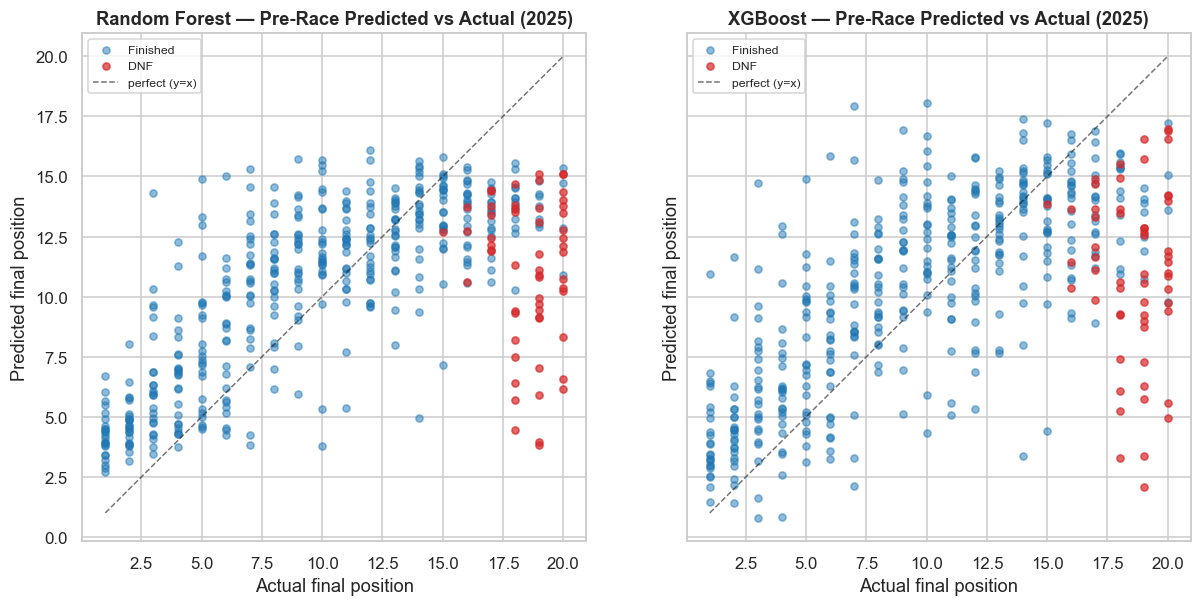

In [8]:
# Plot 1 — Predicted vs Actual (both models), coloured by DNF status.
dnf_mask = test_df["dnf"].astype(bool).values
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
for ax, pred, title in [(axes[0], rf_pred, "Random Forest"), (axes[1], xgb_pred, "XGBoost")]:
    ax.scatter(y_test[~dnf_mask], pred[~dnf_mask], s=22, alpha=0.5, color="#1f77b4", label="Finished")
    ax.scatter(y_test[dnf_mask], pred[dnf_mask], s=22, alpha=0.7, color="#d62728", label="DNF")
    ax.plot([1, 20], [1, 20], "k--", lw=1, alpha=0.6, label="perfect (y=x)")
    ax.set_title(f"{title} — Pre-Race Predicted vs Actual (2025)")
    ax.set_xlabel("Actual final position"); ax.set_ylabel("Predicted final position")
    ax.legend(loc="upper left", fontsize=8)
save_fig(fig, "20_prerace_predicted_vs_actual.png"); plt.show()

  saved -> reports/figures/21_prerace_residual_distribution.png


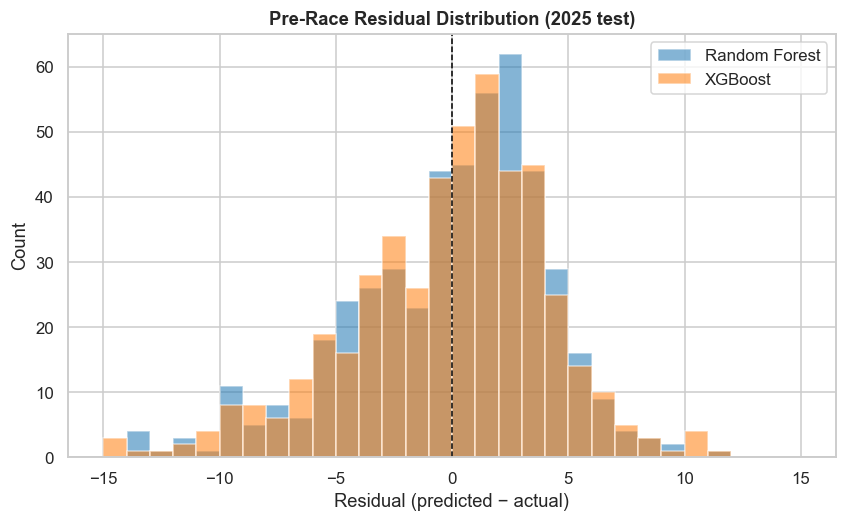

In [23]:
# Plot 2 — Residual distribution (pred - actual), both models.
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.arange(-15, 15.5, 1)
ax.hist(rf_pred - y_test, bins=bins, alpha=0.55, label="Random Forest", color="#1f77b4")
ax.hist(xgb_pred - y_test, bins=bins, alpha=0.55, label="XGBoost", color="#ff7f0e")
ax.axvline(0, color="black", ls="--", lw=1)
ax.set_xlabel("Residual (predicted − actual)"); ax.set_ylabel("Count")
ax.set_title("Pre-Race Residual Distribution (2025 test)"); ax.legend()
save_fig(fig, "21_prerace_residual_distribution.png"); plt.show()

  saved -> reports/figures/22_prerace_mae_by_grid_bucket.png


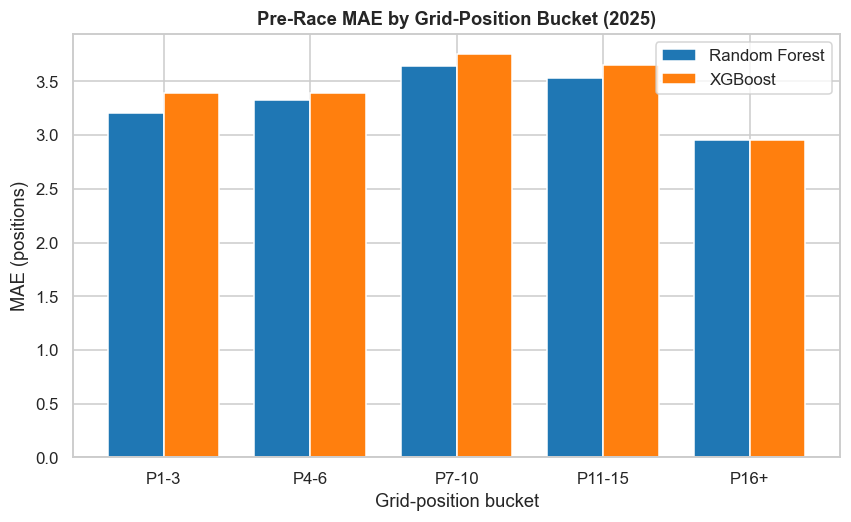

In [9]:
# Plot 3 — MAE by grid-position bucket (pit-lane starts -> grid 21 fall in the last bucket).
buckets = pd.cut(test_df["grid_position"], bins=[-0.1, 3, 6, 10, 15, 21.5],
                 labels=["P1-3", "P4-6", "P7-10", "P11-15", "P16+"])
bdf = pd.DataFrame({"bucket": buckets, "rf_ae": np.abs(rf_pred - y_test),
                    "xgb_ae": np.abs(xgb_pred - y_test)})
bmae = bdf.groupby("bucket", observed=True)[["rf_ae", "xgb_ae"]].mean()
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(bmae)); w = 0.38
ax.bar(x - w/2, bmae["rf_ae"], w, label="Random Forest", color="#1f77b4")
ax.bar(x + w/2, bmae["xgb_ae"], w, label="XGBoost", color="#ff7f0e")
ax.set_xticks(x); ax.set_xticklabels(bmae.index)
ax.set_xlabel("Grid-position bucket"); ax.set_ylabel("MAE (positions)")
ax.set_title("Pre-Race MAE by Grid-Position Bucket (2025)"); ax.legend()
save_fig(fig, "22_prerace_mae_by_grid_bucket.png"); plt.show()

  saved -> reports/figures/23_prerace_cv_score_distribution.png


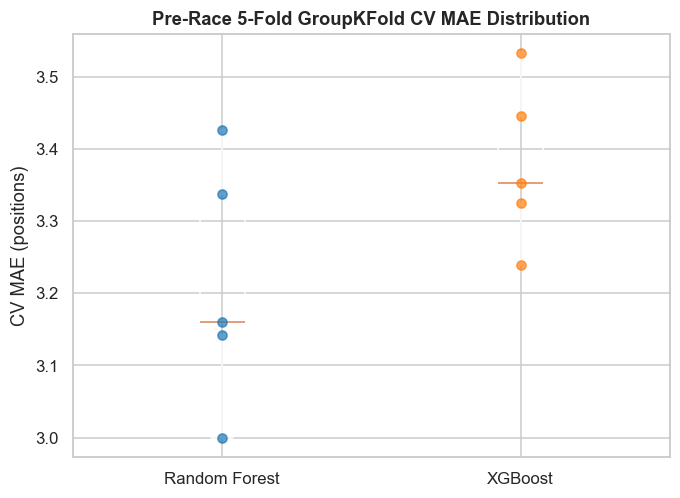

In [25]:
# Plot 4 — CV score distribution (stability).
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([rf_cv, xgb_cv], tick_labels=["Random Forest", "XGBoost"])
ax.scatter(np.ones(len(rf_cv)), rf_cv, color="#1f77b4", alpha=0.7, zorder=3)
ax.scatter(np.full(len(xgb_cv), 2), xgb_cv, color="#ff7f0e", alpha=0.7, zorder=3)
ax.set_ylabel("CV MAE (positions)")
ax.set_title("Pre-Race 5-Fold GroupKFold CV MAE Distribution")
save_fig(fig, "23_prerace_cv_score_distribution.png"); plt.show()

  saved -> reports/figures/24_prerace_per_race_mae_2025.png


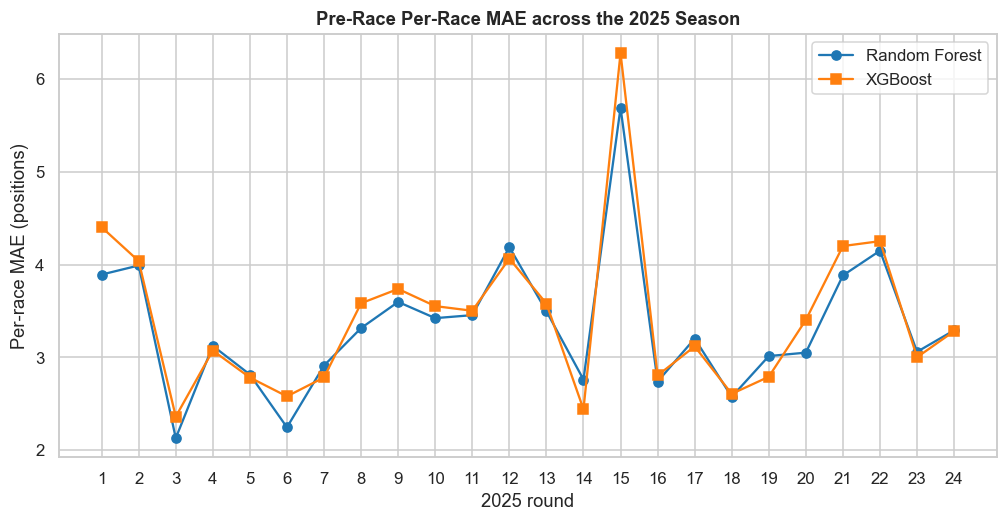

In [10]:
# Plot 5 — Per-race MAE across the 2025 season.
prm = pd.DataFrame({"round": test_df["round"].values,
                    "rf_ae": np.abs(rf_pred - y_test), "xgb_ae": np.abs(xgb_pred - y_test)})
prm = prm.groupby("round")[["rf_ae", "xgb_ae"]].mean().sort_index()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(prm.index, prm["rf_ae"], marker="o", label="Random Forest", color="#1f77b4")
ax.plot(prm.index, prm["xgb_ae"], marker="s", label="XGBoost", color="#ff7f0e")
ax.set_xlabel("2025 round"); ax.set_ylabel("Per-race MAE (positions)")
ax.set_title("Pre-Race Per-Race MAE across the 2025 Season"); ax.legend()
ax.set_xticks(prm.index)
save_fig(fig, "24_prerace_per_race_mae_2025.png"); plt.show()

## Robustness Diagnostics (pre-race)
Same two honesty checks as CP3 — **no retraining, predictions unchanged**:
1. **Finishers-only vs all-drivers error** — isolates ranking skill from unforeseeable retirements.
2. **Paired bootstrap 95% CI on test MAE** — here the key paired comparison is **RF − grid baseline**:
   it tests whether the pre-race model's tiny 0.015-position edge over grid is statistically real or noise.

In [11]:
# --- Diagnostic 1: finishers-only vs all-drivers error (DNFs are unforeseeable retirements) ---
dnf_mask = test_df["dnf"].astype(bool).values
fin = ~dnf_mask
print(f"2025 test rows: {len(y_test)} | finishers: {fin.sum()} | DNFs: {dnf_mask.sum()} ({dnf_mask.mean():.1%})")
print(f"{'model':14s} {'MAE all':>8s} {'MAE finishers':>14s} {'MAE DNFs':>9s} {'Spearman fin':>13s}")
for name, pred in [("Random Forest", rf_pred), ("XGBoost", xgb_pred)]:
    mae_all = mean_absolute_error(y_test, pred)
    mae_fin = mean_absolute_error(y_test[fin], pred[fin])
    mae_dnf = mean_absolute_error(y_test[dnf_mask], pred[dnf_mask])
    sp_fin = spearmanr(y_test[fin], pred[fin]).correlation
    print(f"{name:14s} {mae_all:8.3f} {mae_fin:14.3f} {mae_dnf:9.3f} {sp_fin:13.3f}")
print("\nEven on finishers only, the pre-race model is bounded by what is knowable before lights-out;")
print("DNFs further inflate the all-drivers MAE and are not forecastable from pre-race inputs.")

2025 test rows: 476 | finishers: 419 | DNFs: 57 (12.0%)
model           MAE all  MAE finishers  MAE DNFs  Spearman fin
Random Forest     3.332          2.760     7.530         0.771
XGBoost           3.425          2.858     7.589         0.735

Even on finishers only, the pre-race model is bounded by what is knowable before lights-out;
DNFs further inflate the all-drivers MAE and are not forecastable from pre-race inputs.


RF  pre-race test MAE 3.332  95% CI [3.098, 3.580]
XGB pre-race test MAE 3.425  95% CI [3.177, 3.688]
Paired (RF - grid baseline) diff -0.014  95% CI [-0.249, +0.233]
=> 0 lies inside the CI: the pre-race model does NOT reliably beat the grid baseline.
  saved -> reports/figures/25_prerace_bootstrap_mae_ci.png


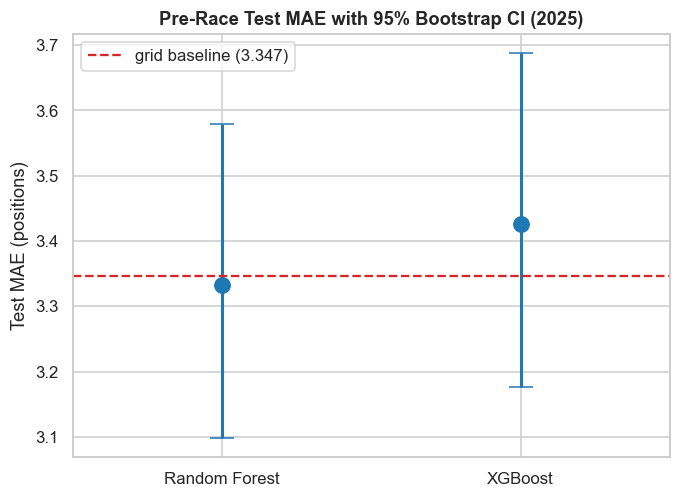

In [12]:
# --- Diagnostic 2: paired bootstrap 95% CI on pre-race test MAE (single held-out season => variance) ---
rng = np.random.default_rng(42)
n, B = len(y_test), 2000
rf_boot = np.empty(B); xgb_boot = np.empty(B)
for b in range(B):
    idx = rng.integers(0, n, n)               # same resample applied to both models (paired)
    yt = y_test[idx]
    rf_boot[b]  = mean_absolute_error(yt, rf_pred[idx])
    xgb_boot[b] = mean_absolute_error(yt, xgb_pred[idx])
ci = lambda a: (a.mean(), np.percentile(a, 2.5), np.percentile(a, 97.5))
rf_mu, rf_lo, rf_hi = ci(rf_boot)
xgb_mu, xgb_lo, xgb_hi = ci(xgb_boot)
g_mu, g_lo, g_hi = ci(rf_boot - baseline_grid)   # paired RF - grid baseline on identical resamples

print(f"RF  pre-race test MAE {rf_m['mae']:.3f}  95% CI [{rf_lo:.3f}, {rf_hi:.3f}]")
print(f"XGB pre-race test MAE {xgb_m['mae']:.3f}  95% CI [{xgb_lo:.3f}, {xgb_hi:.3f}]")
print(f"Paired (RF - grid baseline) diff {g_mu:+.3f}  95% CI [{g_lo:+.3f}, {g_hi:+.3f}]")
print("=> 0 lies inside the CI: the pre-race model does NOT reliably beat the grid baseline."
      if g_lo < 0 < g_hi else "=> CI excludes 0: the pre-race model reliably beats grid.")

fig, ax = plt.subplots(figsize=(7, 5))
xs = [0, 1]
ax.errorbar(xs, [rf_mu, xgb_mu],
            yerr=[[rf_mu - rf_lo, xgb_mu - xgb_lo], [rf_hi - rf_mu, xgb_hi - xgb_mu]],
            fmt="o", ms=10, lw=2, capsize=8, color="#1f77b4")
ax.axhline(baseline_grid, ls="--", color="#d62728", label=f"grid baseline ({baseline_grid:.3f})")
ax.set_xticks(xs); ax.set_xticklabels(["Random Forest", "XGBoost"])
ax.set_xlim(-0.5, 1.5); ax.set_ylabel("Test MAE (positions)")
ax.set_title("Pre-Race Test MAE with 95% Bootstrap CI (2025)"); ax.legend()
save_fig(fig, "25_prerace_bootstrap_mae_ci.png"); plt.show()

## Model Selection
Criteria in order: (1) lower test MAE, (2) higher Spearman r, (3) lower CV std.

In [13]:
def pick(rf_m, xgb_m, rf_cv, xgb_cv):
    if abs(rf_m["mae"] - xgb_m["mae"]) > 1e-6:
        return ("Random Forest", "RF") if rf_m["mae"] < xgb_m["mae"] else ("XGBoost", "XGB")
    if abs(rf_m["spearman"] - xgb_m["spearman"]) > 1e-6:
        return ("Random Forest", "RF") if rf_m["spearman"] > xgb_m["spearman"] else ("XGBoost", "XGB")
    return ("Random Forest", "RF") if rf_cv.std() < xgb_cv.std() else ("XGBoost", "XGB")

selected, tag = pick(rf_m, xgb_m, rf_cv, xgb_cv)
sel_m, sel_cv = (rf_m, rf_cv) if tag == "RF" else (xgb_m, xgb_cv)
reason = (f"lowest test MAE ({sel_m['mae']:.3f}); Spearman r={sel_m['spearman']:.3f}, "
          f"within ±5={sel_m['within_5']:.1%}, CV {sel_cv.mean():.3f}±{sel_cv.std():.3f}")
print("=== PRE-RACE MODEL SELECTION ===")
print(f"Selected: {selected}")
print(f"Reason: {reason}")

=== PRE-RACE MODEL SELECTION ===
Selected: Random Forest
Reason: lowest test MAE (3.332); Spearman r=0.643, within ±5=84.9%, CV 3.248±0.105


## CP3.1 Final Summary — Prediction vs Explanation
The numbers below are the **forecasting** (pre-race) model. Compare them directly to CP3's
**reconstruction** results (notebook `03_model_training.ipynb`):
- The pre-race model should sit **between the grid baseline and the reconstruction model** — that gap
  quantifies how much of the finishing order is decided *during* the race vs predictable beforehand.
- For the thesis: CP3.1 = "how well can we forecast?", CP3 = "what explains the result?" (SHAP in CP4).

In [14]:
def block(name, m, cv):
    return (f"{name}:\n"
            f"  CV MAE    : {cv.mean():.3f} ± {cv.std():.3f}\n"
            f"  Test MAE  : {m['mae']:.3f} positions\n"
            f"  Test R²   : {m['r2']:.3f}\n"
            f"  Spearman r: {m['spearman']:.3f}\n"
            f"  Within ±3 : {m['within_3']:.1%}\n"
            f"  Within ±5 : {m['within_5']:.1%}")

print("=== CP3.1 COMPLETE (pre-race / forecasting model) ===")
print(f"Pre-race features used: {len(FEATURES)}")
print(block("Random Forest", rf_m, rf_cv))
print(block("XGBoost", xgb_m, xgb_cv))
print(f"\nBaselines:\n  Grid position MAE : {baseline_grid:.3f}\n  Mean prediction MAE: {baseline_mean:.3f}")
print(f"\nSelected pre-race model: {selected}")
print(f"Plots saved: {len(saved_figures)} files in reports/figures/ (20-25)")
print("\nCompare to CP3 (full reconstruction set) to quantify the forecast-vs-reconstruction gap.")
print("Notes:")
print("  - Pre-race set excludes all in-race pace/strategy/incident features (true forecasting).")
print("  - is_wet_race kept as a pre-race weather-forecast proxy (assumption; actual wetness is in-race).")
print("  - driver_encoded is an arbitrary label code: form features are the generalisable driver signal.")
print("  - Imputer saved to models/pre_race_imputer.pkl; constructor_season_points uses a 0-fill.")

=== CP3.1 COMPLETE (pre-race / forecasting model) ===
Pre-race features used: 13
Random Forest:
  CV MAE    : 3.248 ± 0.105
  Test MAE  : 3.332 positions
  Test R²   : 0.440
  Spearman r: 0.643
  Within ±3 : 62.0%
  Within ±5 : 84.9%
XGBoost:
  CV MAE    : 3.474 ± 0.113
  Test MAE  : 3.425 positions
  Test R²   : 0.383
  Spearman r: 0.614
  Within ±3 : 62.0%
  Within ±5 : 82.1%

Baselines:
  Grid position MAE : 3.347
  Mean prediction MAE: 4.962

Selected pre-race model: Random Forest
Plots saved: 4 files in reports/figures/ (20-25)

Compare to CP3 (full reconstruction set) to quantify the forecast-vs-reconstruction gap.
Notes:
  - Pre-race set excludes all in-race pace/strategy/incident features (true forecasting).
  - is_wet_race kept as a pre-race weather-forecast proxy (assumption; actual wetness is in-race).
  - driver_encoded is an arbitrary label code: form features are the generalisable driver signal.
  - Imputer saved to models/pre_race_imputer.pkl; constructor_season_points u